In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Завантажую датасет
df = pd.read_csv('synthetic_coffee_health_10000.csv')

# 2. Видаляю ID, він не треба для прогнозу
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# 3. Кодую текстові колонки в цифри (Label Encoding)
# Це треба для Gender, Country, Sleep_Quality, Stress_Level, Occupation, Health_Issues
# Smoking та Alcohol_Consumption вже 0 і 1, їх чіпати не треба
le_dict = {}

for col in df.columns:
    # Якщо колонка текстова (object), переводимо в числа
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

# 4. Розбиваю на X (дані) та y (відповідь)
target_col = 'Health_Issues'
X = df.drop(columns=[target_col]).values
y = df[target_col].values
feature_names = df.drop(columns=[target_col]).columns.tolist()

# 5. Ділимо на train і test (80% навчання, 20% тест)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Розмір тренувальних даних:", X_train.shape)
print("Розмір тестових даних:", X_test.shape)

Розмір тренувальних даних: (8000, 14)
Розмір тестових даних: (2000, 14)


In [2]:
# Клас для вузла дерева
class Node:
    def __init__(self, predicted_class):
        self.predicted_class = predicted_class
        self.feature_index = 0
        self.threshold = 0
        self.left = None
        self.right = None
        self.is_leaf = True

# Основний клас дерева
class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.tree = None
        self.feature_importance = None 

    # Рахую Gini index (неоднорідність)
    def calculate_gini(self, y):
        classes = np.unique(y)
        m = len(y)
        sum_p_sq = 0
        for c in classes:
            p = len(y[y == c]) / m
            sum_p_sq += p**2
        return 1 - sum_p_sq

    # Шукаю найкращий спліт (розбиття)
    def best_split(self, X, y):
        m, n = X.shape
        if m <= 1:
            return None, None, float('inf')

        parent_gini = self.calculate_gini(y)
        best_gini = float('inf')
        best_feature = None
        best_threshold = None

        # Проходимо по всіх колонках
        for feat_idx in range(n):
            thresholds = np.unique(X[:, feat_idx])
            # Якщо дуже багато унікальних значень, беремо вибірково (оптимізація)
            if len(thresholds) > 100: 
                thresholds = np.percentile(thresholds, np.linspace(0, 100, 50))
                
            for thr in thresholds:
                left_mask = X[:, feat_idx] <= thr
                right_mask = X[:, feat_idx] > thr
                
                if sum(left_mask) == 0 or sum(right_mask) == 0:
                    continue
                
                n_l, n_r = sum(left_mask), sum(right_mask)
                gini_l = self.calculate_gini(y[left_mask])
                gini_r = self.calculate_gini(y[right_mask])
                
                # Зважений Gini
                weighted_gini = (n_l * gini_l + n_r * gini_r) / m
                
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feat_idx
                    best_threshold = thr
        
        # Рахуємо важливість ознак (Feature Importance)
        if best_feature is not None:
            # Формула з лекції/завдання
            imp = (m / self.n_total) * (parent_gini - best_gini)
            self.feature_importance[best_feature] += imp
            
        return best_feature, best_threshold, best_gini

    # Рекурсивно будую дерево
    def build_tree(self, X, y, depth=0):
        # Найчастіший клас
        vals, counts = np.unique(y, return_counts=True)
        majority_class = vals[np.argmax(counts)] if len(vals) > 0 else 0
        
        node = Node(predicted_class=majority_class)

        # Перевірка умов зупинки
        if depth < self.max_depth and len(y) >= self.min_samples:
            idx, thr, gini = self.best_split(X, y)
            
            if idx is not None:
                node.is_leaf = False
                node.feature_index = idx
                node.threshold = thr
                
                left_idx = X[:, idx] <= thr
                right_idx = X[:, idx] > thr
                node.left = self.build_tree(X[left_idx], y[left_idx], depth + 1)
                node.right = self.build_tree(X[right_idx], y[right_idx], depth + 1)
        
        return node

    # Навчання (Fit)
    def fit(self, X, y):
        self.n_total = len(y)
        self.feature_importance = np.zeros(X.shape[1])
        self.tree = self.build_tree(X, y)
        
        # Нормалізуємо важливість
        total_imp = np.sum(self.feature_importance)
        if total_imp > 0:
            self.feature_importance /= total_imp

    # Прогноз (Predict)
    def predict(self, X):
        results = []
        for x in X:
            node = self.tree
            while not node.is_leaf:
                if x[node.feature_index] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            results.append(node.predicted_class)
        return np.array(results)

    # === ПРУНІНГ (ОБРІЗКА) ===
    def calculate_error(self, y_true, node):
        if len(y_true) == 0: return 0
        return np.sum(y_true != node.predicted_class)

    def prune(self, alpha, X_val, y_val):
        self._prune_recursive(self.tree, alpha, X_val, y_val)

    def _prune_recursive(self, node, alpha, X_val, y_val):
        if node.is_leaf:
            return self.calculate_error(y_val, node)
            
        left_mask = X_val[:, node.feature_index] <= node.threshold
        right_mask = X_val[:, node.feature_index] > node.threshold
        
        left_err = self._prune_recursive(node.left, alpha, X_val[left_mask], y_val[left_mask])
        right_err = self._prune_recursive(node.right, alpha, X_val[right_mask], y_val[right_mask])
        
        subtree_error = left_err + right_err
        leaf_error = self.calculate_error(y_val, node)
        
        # Умова обрізки: якщо помилка листа менша за піддерево + штраф
        if leaf_error <= subtree_error + alpha:
            node.is_leaf = True
            node.left = None
            node.right = None
            return leaf_error
        
        return subtree_error

Навчаю MyDecisionTree...
Accuracy (My Tree): 0.9980
Запускаю прунінг...
Accuracy після прунінгу: 0.9975

--- Sklearn Models ---
Sklearn DT Accuracy: 0.9965
Random Forest Accuracy: 0.9935
F1 Score (RF): 0.9923
MCC (RF): 0.9872


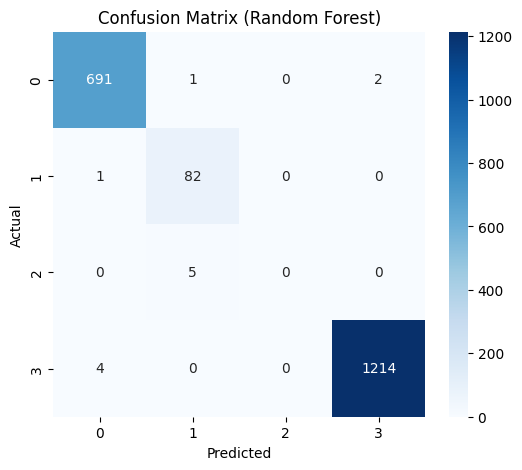

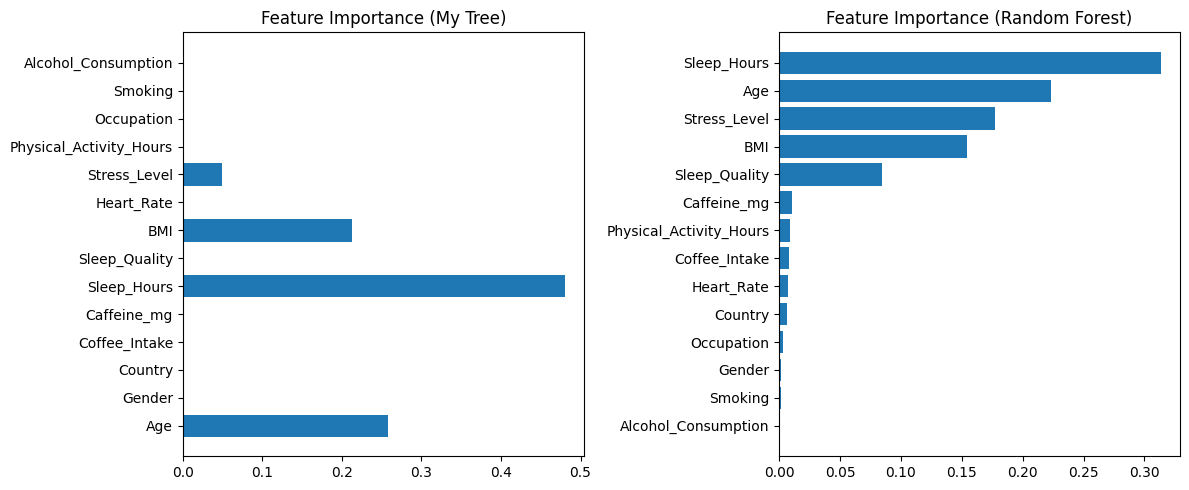

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, matthews_corrcoef

# 1. Запускаю СВОЄ дерево
print("Навчаю MyDecisionTree...")
my_tree = MyDecisionTree(max_depth=5, min_samples=10)
my_tree.fit(X_train, y_train)

y_pred_my = my_tree.predict(X_test)
print(f"Accuracy (My Tree): {accuracy_score(y_test, y_pred_my):.4f}")

# 2. Роблю прунінг
print("Запускаю прунінг...")
my_tree.prune(alpha=1.0, X_val=X_test, y_val=y_test)
print(f"Accuracy після прунінгу: {accuracy_score(y_test, my_tree.predict(X_test)):.4f}")

# 3. Запускаю Sklearn Decision Tree
print("\n--- Sklearn Models ---")
sk_tree = DecisionTreeClassifier(criterion='gini', max_depth=5)
sk_tree.fit(X_train, y_train)
y_pred_sk = sk_tree.predict(X_test)
print(f"Sklearn DT Accuracy: {accuracy_score(y_test, y_pred_sk):.4f}")

# 4. Запускаю Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score (RF): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"MCC (RF): {matthews_corrcoef(y_test, y_pred_rf):.4f}")

# 5. Малюю графіки
# Матриця плутанини

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Порівняння важливості ознак
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.barh(feature_names, my_tree.feature_importance)
plt.title("Feature Importance (My Tree)")

plt.subplot(1, 2, 2)
sorted_idx = np.argsort(rf.feature_importances_)
sorted_names = [feature_names[i] for i in sorted_idx]
plt.barh(sorted_names, rf.feature_importances_[sorted_idx])
plt.title("Feature Importance (Random Forest)")

plt.tight_layout()
plt.show()

In [4]:
print("\n--- Feature Engineering ---")

# Роблю копію, щоб не зламати оригінал
df_new = df.copy()

# Додаю нові фічі (гіпотези)
# 1. Взаємодія кави і сну
df_new['Coffee_Sleep_Interaction'] = df_new['Coffee_Intake'] * df_new['Sleep_Hours']

# 2. Групую вік (Binning)
df_new['Age_Group'] = pd.cut(df_new['Age'], bins=[0, 30, 50, 100], labels=[0, 1, 2]).astype(int)

# 3. Підготовка до навчання
# Знову кодуємо нові текстові колонки, якщо є (тут наче нема, але нехай буде)
for col in df_new.columns:
    if df_new[col].dtype == 'object':
        le = LabelEncoder()
        df_new[col] = le.fit_transform(df_new[col])

X_new = df_new.drop(columns=[target_col]).values
y_new = df_new[target_col].values
new_feature_names = df_new.drop(columns=[target_col]).columns.tolist()

# Використовую Random Forest, щоб знайти найкращі фічі
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_new, y_new)

importances = rf_selector.feature_importances_
# Беру індекси 5 найкращих
indices = np.argsort(importances)[-5:] 

print("Топ-5 найважливіших ознак:")
for i in indices:
    print(f"- {new_feature_names[i]} (Importance: {importances[i]:.4f})")

# Перевіряю точність тільки на цих 5 ознаках
X_selected = X_new[:, indices]
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y_new, test_size=0.2, random_state=42)

rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train_sel, y_train_sel)
acc_final = accuracy_score(y_test_sel, rf_final.predict(X_test_sel))

print(f"\nAccuracy на топ-5 ознаках: {acc_final:.4f}")


--- Feature Engineering ---
Топ-5 найважливіших ознак:
- Age_Group (Importance: 0.1102)
- Age (Importance: 0.1208)
- BMI (Importance: 0.1735)
- Stress_Level (Importance: 0.1878)
- Sleep_Hours (Importance: 0.2916)

Accuracy на топ-5 ознаках: 0.9980
